In [3]:
import pandas as pd
import xarray as xr
import gcsfs

In [8]:
%pip install xarray zarr gcsfs cftime

# Load CMIP6 catalog
df = pd.read_csv(
    "https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv"
)

# Example: historical monthly temperature
subset = df.query(
    "activity_id=='CMIP' & table_id=='Amon' & variable_id=='tas' & experiment_id=='historical'"
)

# Connect anonymously
gcs = gcsfs.GCSFileSystem(token='anon')

# Pick one model
zstore = subset.iloc[0].zstore

# Open dataset
mapper = gcs.get_mapper(zstore)
ds = xr.open_zarr(mapper, consolidated=True)

ds

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<xarray.Dataset> Size: 411MB
Dimensions:    (time: 1980, lat: 180, lon: 288, bnds: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * bnds       (bnds) float64 16B 1.0 2.0
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    time_bnds  (time, bnds) object 32kB ...
    height     float64 8B ...
Data variables:
    tas        (time, lat, lon) float32 411MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  73000.0
    comment:                <null ref>
    ...                     ...
    table_id:               Amon
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/5bec2536-493f-47e2-ab65-73279db597b5...
    variable_id:            tas
    variant_info:           N/A
    variant_label:          r3i1p1f1

In [9]:
# ============================================================
# DSC 106 Project 3 — CMIP6 US Tourism Climate Index Pipeline
# ============================================================

import pandas as pd
import xarray as xr
import gcsfs
import numpy as np
import json

# ── 0. Connect to GCS ──────────────────────────────────────
gcs = gcsfs.GCSFileSystem(token='anon')
catalog_url = "https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv"
df = pd.read_csv(catalog_url)

# ── 1. Helper: load ONE variable from ONE model/scenario ───
def load_cmip6(variable_id, experiment_id, table_id='Amon', model=None):
    """
    Returns an xr.Dataset for the requested variable/experiment.
    Picks the first available model unless `model` is specified.
    """
    query = (
        f"activity_id=='CMIP' & table_id=='{table_id}' "
        f"& variable_id=='{variable_id}' "
        f"& experiment_id=='{experiment_id}'"
    )
    if experiment_id.startswith('ssp'):
        query = query.replace("activity_id=='CMIP'", "activity_id=='ScenarioMIP'")

    subset = df.query(query)
    if subset.empty:
        raise ValueError(f"No data found for {variable_id} / {experiment_id}")

    if model:
        row = subset[subset.source_id == model].iloc[0]
    else:
        row = subset.iloc[0]

    print(f"  Loading: {row.source_id} | {variable_id} | {experiment_id}")
    mapper = gcs.get_mapper(row.zstore)
    ds = xr.open_zarr(mapper, consolidated=True)
    return ds

# ── 2. Define US Bounding Box & Regional Masks ─────────────
#
# All coordinates are (lat_min, lat_max, lon_min, lon_max)
# CMIP6 uses 0–360 longitude, so US west longitudes need +360

US_REGIONS = {
    "West Coast": {
        "lat": (32.0, 49.0),
        "lon": (235.0, 247.0),   # roughly -125 to -113
        "color": "#2196F3",
        "pref": "mild_dry"
    },
    "Northwest / Mountain": {
        "lat": (42.0, 49.0),
        "lon": (247.0, 258.0),   # roughly -113 to -102
        "color": "#4CAF50",
        "pref": "cool_snow"
    },
    "South": {
        "lat": (25.0, 37.0),
        "lon": (258.0, 280.0),   # roughly -102 to -80
        "color": "#FF9800",
        "pref": "warm_tolerable"
    },
    "East Coast": {
        "lat": (37.0, 47.0),
        "lon": (280.0, 295.0),   # roughly -80 to -65
        "color": "#9C27B0",
        "pref": "moderate_seasonal"
    },
}

def crop_to_region(da, region):
    """Slice a DataArray to a named US region."""
    r = US_REGIONS[region]
    lat_min, lat_max = r["lat"]
    lon_min, lon_max = r["lon"]

    # Handle lat ordering (some models go 90→-90)
    lat = da.lat
    if float(lat[0]) > float(lat[-1]):
        da = da.sel(lat=slice(lat_max, lat_min))
    else:
        da = da.sel(lat=slice(lat_min, lat_max))

    da = da.sel(lon=slice(lon_min, lon_max))
    return da

def regional_mean(da, region):
    """Spatially average over a region, weighted by cos(lat)."""
    da_r = crop_to_region(da, region)
    weights = np.cos(np.deg2rad(da_r.lat))
    return da_r.weighted(weights).mean(dim=["lat", "lon"])

# ── 3. Tourism Climate Suitability Index (TCSI) ─────────────
#
# Each region has its own scoring function → returns 0–1 value
# Higher = better tourism climate that year/season

def score_temperature(tas_c, ideal_min, ideal_max, hard_min, hard_max):
    """
    Trapezoidal comfort score for temperature in Celsius.
    Returns 1.0 inside [ideal_min, ideal_max], 0.0 outside [hard_min, hard_max].
    """
    score = np.where(
        (tas_c >= ideal_min) & (tas_c <= ideal_max), 1.0,
        np.where(
            (tas_c >= hard_min) & (tas_c < ideal_min),
            (tas_c - hard_min) / (ideal_min - hard_min),
            np.where(
                (tas_c > ideal_max) & (tas_c <= hard_max),
                (hard_max - tas_c) / (hard_max - ideal_max),
                0.0
            )
        )
    )
    return float(np.clip(score, 0, 1))

def compute_tcsi(tas_series_k, pr_series_mm_day, region_name, prsn_series=None):
    """
    Given monthly time series (already spatially averaged), compute annual TCSI.

    tas_series_k      : xr.DataArray  [time]  temperature in Kelvin
    pr_series_mm_day  : xr.DataArray  [time]  precip in mm/day
    region_name       : str
    prsn_series       : xr.DataArray or None   snowfall in mm/day (Mountain only)

    Returns: pd.Series indexed by year
    """
    tas_c = tas_series_k - 273.15
    df_r = pd.DataFrame({
        "year":  tas_c.time.dt.year.values,
        "month": tas_c.time.dt.month.values,
        "tas_c": tas_c.values,
        "pr":    pr_series_mm_day.values,
    })
    if prsn_series is not None:
        df_r["prsn"] = prsn_series.values

    results = []
    for year, grp in df_r.groupby("year"):
        t_mean = grp["tas_c"].mean()
        pr_ann = grp["pr"].mean()  # mm/day annual average

        # ── Region-specific scoring ──────────────────────
        if region_name == "West Coast":
            # Ideal: 12–22°C, very dry summers good for tourism
            t_score = score_temperature(t_mean, 12, 22, 0, 32)
            # Penalty for high precip (>4 mm/day avg = very wet)
            p_score = float(np.clip(1 - (pr_ann / 6.0), 0, 1))
            tcsi = 0.6 * t_score + 0.4 * p_score

        elif region_name == "Northwest / Mountain":
            # Skiing needs cold winters; summer hiking needs mild temps
            winter_temp = grp[grp.month.isin([12,1,2])]["tas_c"].mean()
            summer_temp = grp[grp.month.isin([6,7,8])]["tas_c"].mean()
            cold_score  = float(np.clip((5 - winter_temp) / 15, 0, 1))  # colder=better
            mild_score  = score_temperature(summer_temp, 15, 25, 5, 35)
            # Snowfall score if available
            if "prsn" in grp.columns:
                snow_ann = grp[grp.month.isin([11,12,1,2,3])]["prsn"].mean()
                snow_score = float(np.clip(snow_ann / 5.0, 0, 1))
                tcsi = 0.35 * cold_score + 0.25 * mild_score + 0.4 * snow_score
            else:
                # Approximate: cold + high winter precip → likely snow
                win_pr = grp[grp.month.isin([11,12,1,2,3])]["pr"].mean()
                snow_proxy = float(np.clip(win_pr / 4.0, 0, 1)) * cold_score
                tcsi = 0.4 * cold_score + 0.3 * mild_score + 0.3 * snow_proxy

        elif region_name == "South":
            # Warm but not dangerously hot; humidity penalty modeled via precip
            t_score = score_temperature(t_mean, 18, 28, 10, 38)
            # Too much rain (humid summer) is bad
            p_score = float(np.clip(1 - (pr_ann / 8.0), 0, 1))
            # Extra penalty if mean temp > 33°C (heat stress)
            heat_penalty = float(np.clip((t_mean - 33) / 5, 0, 1)) if t_mean > 33 else 0
            tcsi = 0.5 * t_score + 0.3 * p_score - 0.2 * heat_penalty
            tcsi = float(np.clip(tcsi, 0, 1))

        elif region_name == "East Coast":
            # Moderate all-season tourism; prefers 10–24°C range
            t_score = score_temperature(t_mean, 10, 24, -5, 34)
            # Moderate rain is fine; extreme flooding bad
            p_score = float(np.clip(1 - max(0, pr_ann - 3) / 5.0, 0, 1))
            tcsi = 0.65 * t_score + 0.35 * p_score

        else:
            tcsi = 0.5

        results.append({"year": year, "tcsi": float(np.clip(tcsi, 0, 1))})

    return pd.DataFrame(results).set_index("year")["tcsi"]

# ── 4. Load Data for All Scenarios ──────────────────────────

SCENARIOS = {
    "historical": "historical",
    "ssp126":     "ssp126",   # Low emissions
    "ssp245":     "ssp245",   # Intermediate
    "ssp585":     "ssp585",   # High emissions
}

# Pick ONE model for consistency across scenarios
# (BCC-CSM2-MR has good coverage; swap to any model you prefer)
TARGET_MODEL = "BCC-CSM2-MR"

all_results = {}  # { scenario: { region: pd.Series(year→tcsi) } }

for scen_label, experiment_id in SCENARIOS.items():
    print(f"\n{'='*50}")
    print(f"Loading scenario: {scen_label}")
    print('='*50)

    try:
        # Load temperature
        ds_tas = load_cmip6("tas", experiment_id, model=TARGET_MODEL)
        tas    = ds_tas["tas"]

        # Load precipitation (convert from kg/m²/s to mm/day: ×86400)
        ds_pr  = load_cmip6("pr", experiment_id, model=TARGET_MODEL)
        pr     = ds_pr["pr"] * 86400.0

        # Try to load snowfall (optional)
        try:
            ds_prsn = load_cmip6("prsn", experiment_id, model=TARGET_MODEL)
            prsn    = ds_prsn["prsn"] * 86400.0
        except Exception:
            print("  prsn not available — will use proxy")
            prsn = None

        # Time slice
        if experiment_id == "historical":
            time_slice = slice("1950", "2014")
        else:
            time_slice = slice("2015", "2100")

        tas  = tas.sel(time=time_slice)
        pr   = pr.sel(time=time_slice)
        if prsn is not None:
            prsn = prsn.sel(time=time_slice)

        scen_results = {}
        for region in US_REGIONS:
            print(f"  Computing TCSI for {region}...")
            tas_r  = regional_mean(tas, region)
            pr_r   = regional_mean(pr, region)
            prsn_r = regional_mean(prsn, region) if prsn is not None else None

            tcsi_series = compute_tcsi(tas_r, pr_r, region, prsn_series=prsn_r)
            scen_results[region] = tcsi_series

        all_results[scen_label] = scen_results

    except Exception as e:
        print(f"  ERROR for {scen_label}: {e}")

print("\nDone computing TCSI!")

# ── 5. Combine into a Tidy DataFrame & Export to JSON ───────

rows = []
for scen, region_dict in all_results.items():
    for region, series in region_dict.items():
        for year, tcsi in series.items():
            rows.append({
                "scenario": scen,
                "region":   region,
                "year":     int(year),
                "tcsi":     round(float(tcsi), 4)
            })

df_final = pd.DataFrame(rows)

# Save CSV for inspection
df_final.to_csv("tcsi_us_regions.csv", index=False)
print("Saved: tcsi_us_regions.csv")

# Save JSON for D3
json_out = df_final.to_dict(orient="records")
with open("tcsi_us_regions.json", "w") as f:
    json.dump(json_out, f)
print("Saved: tcsi_us_regions.json")

df_final.head(20)


Loading scenario: historical
  Loading: BCC-CSM2-MR | tas | historical
  Loading: BCC-CSM2-MR | pr | historical
  Loading: BCC-CSM2-MR | prsn | historical
  Computing TCSI for West Coast...
  Computing TCSI for Northwest / Mountain...
  Computing TCSI for South...
  Computing TCSI for East Coast...

Loading scenario: ssp126
  Loading: BCC-CSM2-MR | tas | ssp126
  Loading: BCC-CSM2-MR | pr | ssp126
  Loading: BCC-CSM2-MR | prsn | ssp126
  Computing TCSI for West Coast...
  Computing TCSI for Northwest / Mountain...
  Computing TCSI for South...
  Computing TCSI for East Coast...

Loading scenario: ssp245
  Loading: BCC-CSM2-MR | tas | ssp245
  Loading: BCC-CSM2-MR | pr | ssp245
  Loading: BCC-CSM2-MR | prsn | ssp245
  Computing TCSI for West Coast...
  Computing TCSI for Northwest / Mountain...
  Computing TCSI for South...
  Computing TCSI for East Coast...

Loading scenario: ssp585
  Loading: BCC-CSM2-MR | tas | ssp585
  Loading: BCC-CSM2-MR | pr | ssp585
  Loading: BCC-CSM2-MR | prs

,scenario,region,year,tcsi
0,historical,West Coast,1950,0.6809
1,historical,West Coast,1951,0.6891
2,historical,West Coast,1952,0.6670
3,historical,West Coast,1953,0.7257
4,historical,West Coast,1954,0.6762
5,historical,West Coast,1955,0.6806
6,historical,West Coast,1956,0.6459
7,historical,West Coast,1957,0.6636
8,historical,West Coast,1958,0.7440
9,historical,West Coast,1959,0.7091


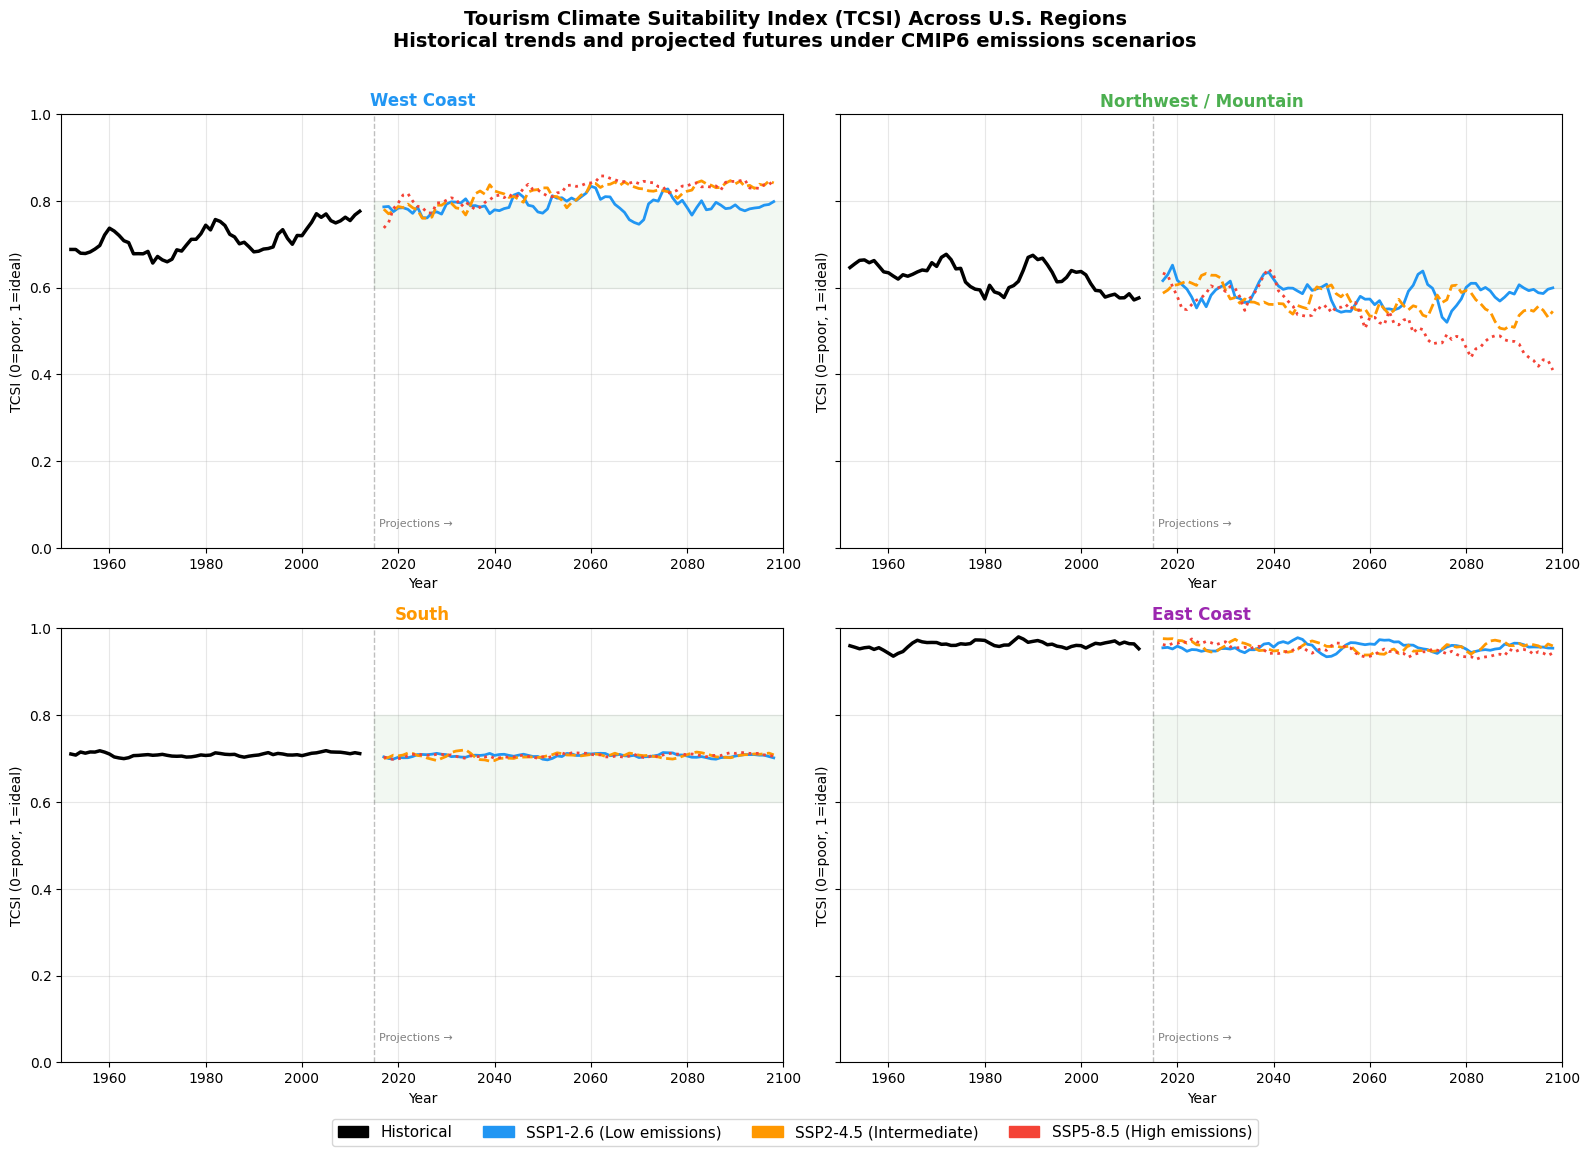

Saved: tcsi_exploratory.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=True)
fig.suptitle(
    "Tourism Climate Suitability Index (TCSI) Across U.S. Regions\n"
    "Historical trends and projected futures under CMIP6 emissions scenarios",
    fontsize=14, fontweight='bold', y=1.01
)

REGION_LIST = list(US_REGIONS.keys())
SCENARIO_STYLES = {
    "historical": dict(color="black",   lw=2.5, ls="-",  label="Historical"),
    "ssp126":     dict(color="#2196F3", lw=2,   ls="-",  label="SSP1-2.6 (Low emissions)"),
    "ssp245":     dict(color="#FF9800", lw=2,   ls="--", label="SSP2-4.5 (Intermediate)"),
    "ssp585":     dict(color="#F44336", lw=2,   ls=":",  label="SSP5-8.5 (High emissions)"),
}

for ax, region in zip(axes.flat, REGION_LIST):
    color = US_REGIONS[region]["color"]

    for scen, style in SCENARIO_STYLES.items():
        if scen not in all_results or region not in all_results[scen]:
            continue
        series = all_results[scen][region]
        # Smooth with 5-year rolling average for clarity
        smoothed = series.rolling(5, center=True).mean()
        ax.plot(smoothed.index, smoothed.values, **style)

    # Add vertical line at scenario split
    ax.axvline(2015, color="gray", lw=1, ls="--", alpha=0.5)
    ax.text(2016, 0.05, "Projections →", fontsize=8, color="gray")

    ax.set_title(region, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel("Year")
    ax.set_ylabel("TCSI (0=poor, 1=ideal)")
    ax.set_ylim(0, 1)
    ax.set_xlim(1950, 2100)
    ax.grid(alpha=0.3)
    ax.fill_between(smoothed.index, 0.6, 0.8, alpha=0.05, color='green',
                    label="Comfortable zone")

# Shared legend
handles = [mpatches.Patch(color=s["color"], label=s["label"])
           for s in SCENARIO_STYLES.values()]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.03), fontsize=11)

plt.tight_layout()
plt.savefig("tcsi_exploratory.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tcsi_exploratory.png")

In [ ]:
import json

rows = []
for scen, region_dict in all_results.items():
    for region, series in region_dict.items():
        for year, tcsi in series.items():
            rows.append({
                "scenario": scen,
                "region":   region,
                "year":     int(year),
                "tcsi":     round(float(tcsi), 4)
            })

with open("tcsi_us_regions.json", "w") as f:
    json.dump(rows, f)

print(f"Done! Saved {len(rows)} rows to tcsi_us_regions.json")